In [ ]:
#Para el entrenamiento
#pip install wandb

In [3]:
import re
import os
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset, DatasetDict
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


column_names = ['label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party',
                'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts',
                'pants_on_fire_counts', 'context']

train_df = pd.read_csv("train.tsv", sep='\t', names=column_names).dropna(subset=["label", "statement"])
valid_df = pd.read_csv("valid.tsv", sep='\t', names=column_names).dropna(subset=["label", "statement"])
test_df = pd.read_csv("test.tsv", sep='\t', names=column_names).dropna(subset=["label", "statement"])

# Mapeo de etiquetas a números
label_map = {
    'pants-fire': 0,
    'false': 1,
    'barely-true': 2,
    'half-true': 3,
    'mostly-true': 4,
    'true': 5
}

train_df['label'] = train_df['label'].map(label_map)
valid_df['label'] = valid_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)


#Preprocesamiento del dataset
#Limpieza básica del texto
def limpiar_texto(texto):
    texto = texto.lower()  # minúsculas
    texto = re.sub(r"http\S+", "", texto)  # quitar URLs
    texto = re.sub(r"[^a-zA-Z0-9\s]", "", texto)  # quitar símbolos raros
    texto = re.sub(r"\s+", " ", texto).strip()  # quitar espacios extras
    return texto

# Aplicar al dataframe
for df in [train_df, valid_df, test_df]:
    df["statement"] = df["statement"].apply(limpiar_texto)

train_df["statement"].sample(5)

,statement
6364.json,says us senate candidate eric hovde has no pro...
5407.json,says sixtytwo percent of small businesses over...
4254.json,says adam hasners record includes requesting o...
5970.json,says williamson county attorney jana duty has ...
6168.json,new jerseys citizens are working at the highes...


In [6]:
#Convertir a formato Dataset de HuggingFace
train_ds = Dataset.from_pandas(train_df[['statement', 'label']], preserve_index=False)
valid_ds = Dataset.from_pandas(valid_df[['statement', 'label']], preserve_index=False)
test_ds = Dataset.from_pandas(test_df[['statement', 'label']], preserve_index=False)

dataset = DatasetDict({
    'train': train_ds,
    'validation': valid_ds,
    'test': test_ds
})

#Tokenización
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(example):
    return tokenizer(example["statement"], truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

#Definir el modelo
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=6)

#Configurar Trainer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {
        "accuracy": accuracy_score(p.label_ids, preds),
        "f1": f1_score(p.label_ids, preds, average="weighted")
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",                # <--- aquí el cambio importante
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=10,
)
#Desactiva WandB para que no pida login
os.environ["WANDB_DISABLED"] = "true"

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

#Entrenamiento del modelo
trainer.train()

#Evaluación en test
metrics = trainer.evaluate(tokenized_datasets["test"])
print(metrics)

Map:   0%|          | 0/10240 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.701400,1.693032,0.260125,0.220769
2,1.614900,1.698518,0.271028,0.261432
3,1.388400,1.749962,0.271028,0.269238


{'eval_loss': 1.6748802661895752, 'eval_accuracy': 0.2517758484609313, 'eval_f1': 0.21158127600458937, 'eval_runtime': 3.6446, 'eval_samples_per_second': 347.642, 'eval_steps_per_second': 21.951, 'epoch': 3.0}


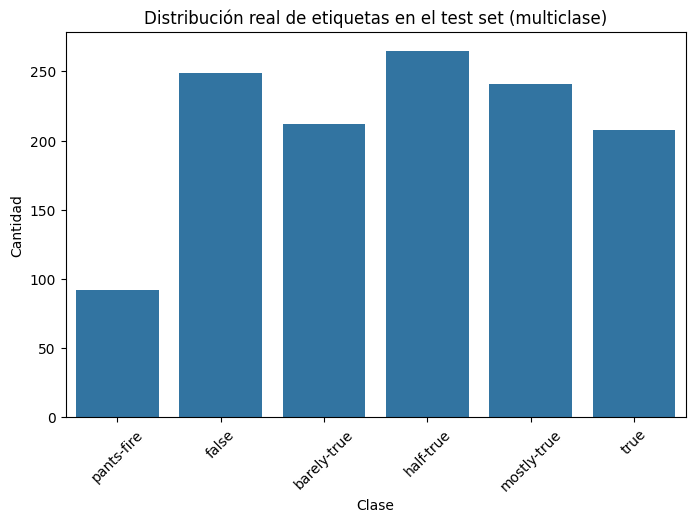

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

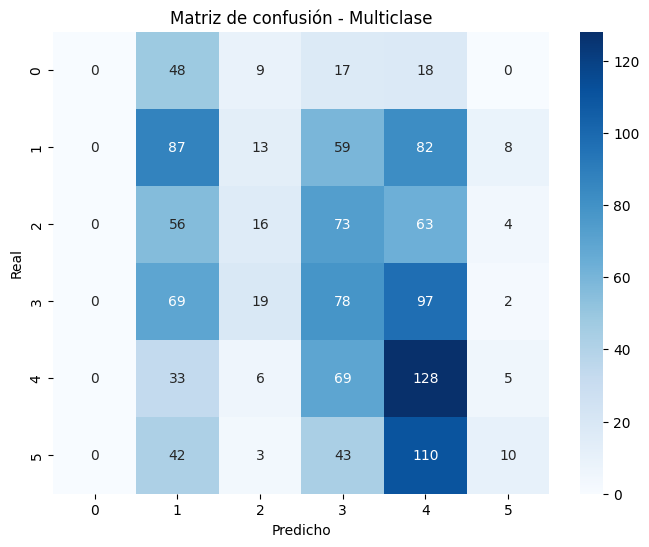

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

              precision    recall  f1-score   support

  pants-fire       0.00      0.00      0.00        92
       false       0.26      0.35      0.30       249
 barely-true       0.24      0.08      0.12       212
   half-true       0.23      0.29      0.26       265
 mostly-true       0.26      0.53      0.35       241
        true       0.34      0.05      0.08       208

    accuracy                           0.25      1267
   macro avg       0.22      0.22      0.18      1267
weighted avg       0.25      0.25      0.21      1267



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
predictions_output = trainer.predict(tokenized_datasets["test"])

# Predicciones como etiquetas (0–5)
predicted_labels = np.argmax(predictions_output.predictions, axis=1)

# Reales
true_labels = predictions_output.label_ids

# Mapear valores numéricos a nombres de clase
label_map_inv = {
    0: 'pants-fire',
    1: 'false',
    2: 'barely-true',
    3: 'half-true',
    4: 'mostly-true',
    5: 'true'
}

# Aplicar el mapeo a la columna de etiquetas reales
etiquetas = test_df['label'].map(label_map_inv)

# Gráfico de barras
plt.figure(figsize=(8,5))
sns.countplot(x=etiquetas, order=label_map_inv.values())
plt.title('Distribución real de etiquetas en el test set (multiclase)')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()


#Matriz de confusión
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión - Multiclase')
plt.show()


# Reporte completo
print(classification_report(true_labels, predicted_labels, target_names=[
    "pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"
]))